Assignment Details:



*   Pick any school in this dataset as an initial comparison point.
*   Pick a feature/measure/score
* Compare the above school to either the entire dataset, other schools in the borough, schools in a particular disctrict, or another comparison.
* Include descriptive statistics
* Include one or more cleaning tasks
* Include one or more visualizations
* Finalize with a brief conclusion statement (maximum three sentences)



In [118]:
#Import pandas, seaborn, matplotlib libraries
#Left-justify all visualizations

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [119]:
#Import data

schools_data = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

Conduct preliminary investigation of the dataset.
* Find the size of the dataset
* Identify the columns
* Determine if there are null or missing values
* Answer some general questions about the dataset as a whole

In [120]:
#Find out how big the data set is (rows, columns)

schools_data.shape

(212331, 15)

In [121]:
#What are the columns of information?

schools_data.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [122]:
#Preview the data by looking at the first 15 rows
  #It appears that there are missing values noted with "s" and "na"
    #Question for the originator of the data: what does "s" stand for? Does it mean the sample size is too small?

schools_data.head(15)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na
5,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2015,9,67.4,3,33.3,6,66.7,0,0,na,na
6,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2016,15,72.6,2,13.3,13,86.7,5,33.3,na,na
7,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2017,9,64.4,5,55.6,4,44.4,1,11.1,na,na
8,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2015,49,78.4,1,2,48,98,23,46.9,48,98
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79,9,17.6,42,82.4,33,64.7,40,78.4


In [123]:
#Preview the data by looking at the last 15 rows
  #This also shows missing values with "s" and "na" noted

schools_data.tail(15)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
212316,84X706,Harriet Tubman Charter School,K-8,Living Environment,2015,1,s,s,s,s,s,s,s,na,na
212317,84X706,Harriet Tubman Charter School,K-8,U.S. History and Government,2017,3,s,s,s,s,s,s,s,na,na
212318,84X717,Icahn Charter School,K-8,Common Core Algebra,2015,5,s,s,s,s,s,s,s,na,na
212319,84X717,Icahn Charter School,K-8,Common Core Algebra,2015,2,s,s,s,s,s,s,s,na,na
212320,84X717,Icahn Charter School,K-8,Common Core Algebra,2016,8,87.9,0,0,8,100,7,87.5,8,100
212321,84X717,Icahn Charter School,K-8,Common Core Algebra,2016,6,87.2,0,0,6,100,6,100,6,100
212322,84X717,Icahn Charter School,K-8,Common Core Algebra,2017,6,87,0,0,6,100,6,100,6,100
212323,84X717,Icahn Charter School,K-8,Common Core Algebra,2017,6,88.3,0,0,6,100,5,83.3,6,100
212324,84X717,Icahn Charter School,K-8,Living Environment,2015,8,76.5,1,12.5,7,87.5,2,25,na,na
212325,84X717,Icahn Charter School,K-8,Living Environment,2015,6,79.8,0,0,6,100,2,33.3,na,na


In [124]:
#How many null values are in the data set?

schools_data.isnull().sum()

,0
School DBN,0
School Name,0
School Level,0
Regents Exam,10
Year,0
Total Tested,0
Mean Score,0
Number Scoring Below 65,0
Percent Scoring Below 65,0
Number Scoring 65 or Above,0


In [125]:
#Is the school DBN a unique identifier?

schools_data["School DBN"].is_unique

False

In [126]:
#Create a unique identifier with the existing index

schools_data = schools_data.reset_index()
print(schools_data.head())

   index School DBN                     School Name School Level  \
0      0     01M034  P.S. 034 Franklin D. Roosevelt          K-8   
1      1     01M034  P.S. 034 Franklin D. Roosevelt          K-8   
2      2     01M034  P.S. 034 Franklin D. Roosevelt          K-8   
3      3     01M140          P.S. 140 Nathan Straus          K-8   
4      4     01M140          P.S. 140 Nathan Straus          K-8   

          Regents Exam  Year  Total Tested Mean Score Number Scoring Below 65  \
0  Common Core Algebra  2017             4          s                       s   
1   Living Environment  2015            16       77.9                       1   
2   Living Environment  2016             9         74                       1   
3  Common Core Algebra  2016             3          s                       s   
4  Common Core Algebra  2017             2          s                       s   

  Percent Scoring Below 65 Number Scoring 65 or Above  \
0                        s                     

In [127]:
#How many schools are represented in the data?

schools_data["School DBN"].nunique()

1018

In [128]:
#How often do schools appear in the data?

schools_data["School DBN"].value_counts()

,count
School DBN,
26Q430,490
22K425,490
30Q450,489
21K525,489
21K540,488
...,...
19K302,5
19K166,5
19K202,5


In [129]:
#Describe the frequency of each school appearing in the data

schools_data["School DBN"].value_counts().describe()

,count
count,1018.000000
mean,208.576621
std,161.687872
min,5.000000
25%,57.000000
50%,182.000000
75%,372.000000
max,490.000000


In [130]:
#Find the number of unique schools per borough

unique_schools = schools_data["School DBN"].unique()

Bronx = "X"
Bronx_count = sum(value.count(Bronx) for value in unique_schools)
print("Number of Bronx schools: "+str(Bronx_count))

Manhattan = "M"
Manhattan_count = sum(value.count(Manhattan) for value in unique_schools)
print("Number of Manhattan schools: "+str(Manhattan_count))

Queens = "Q"
Queens_count = sum(value.count(Queens) for value in unique_schools)
print("Number of Queens schools: "+str(Queens_count))

Brooklyn = "K"
Brooklyn_count = sum(value.count(Brooklyn) for value in unique_schools)
print("Number of Brooklyn schools: "+str(Brooklyn_count))

Staten = "R"
Staten_count = sum(value.count(Staten) for value in unique_schools)
print("Number of Staten Island schools: "+str(Staten_count))


Number of Bronx schools: 254
Number of Manhattan schools: 223
Number of Queens schools: 181
Number of Brooklyn schools: 331
Number of Staten Island schools: 29


In [131]:
#Pick a random school from the dataset for comparison

schools_data.sample(1,random_state=1)

,index,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
61468,61468,03M862,Mott Hall II,Junior High-Intermediate-Middle,Common Core Algebra,2016,7,80.7,0,0,7,100,5,71.4,7,100


**Random School Regents Record for Comparison**
*   School: Mott Hall II (index #61468, DBN #03M862)
*   School Level: Junior High-Intermediate-Middle
* Regents Exam: Common Core Algebra
* Year: 2016

In [132]:
#How many times does Mott Hall II appear in the dataset?

mott_hall2 = schools_data[schools_data["School DBN"] == "03M862"]
mott_hall2["index"].count()

np.int64(72)

In [133]:
mott_hall2.head(72)

,index,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
2875,2875,03M862,Mott Hall II,Junior High-Intermediate-Middle,Common Core Algebra,2015,47,72,4,8.5,43,91.5,4,8.5,35,74.5
2876,2876,03M862,Mott Hall II,Junior High-Intermediate-Middle,Common Core Algebra,2016,53,79.8,1,1.9,52,98.1,29,54.7,49,92.5
2877,2877,03M862,Mott Hall II,Junior High-Intermediate-Middle,Common Core Algebra,2017,55,82.9,1,1.8,54,98.2,46,83.6,54,98.2
2878,2878,03M862,Mott Hall II,Junior High-Intermediate-Middle,Living Environment,2015,74,79.6,4,5.4,70,94.6,42,56.8,na,na
2879,2879,03M862,Mott Hall II,Junior High-Intermediate-Middle,Living Environment,2016,113,81.1,7,6.2,106,93.8,71,62.8,na,na
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151495,151495,03M862,Mott Hall II,Junior High-Intermediate-Middle,Living Environment,2017,12,83.3,0,0,12,100,9,75,na,na
151496,151496,03M862,Mott Hall II,Junior High-Intermediate-Middle,Living Environment,2017,23,76.9,2,8.7,21,91.3,11,47.8,na,na
151497,151497,03M862,Mott Hall II,Junior High-Intermediate-Middle,Living Environment,2017,32,79.4,1,3.1,31,96.9,16,50,na,na
151498,151498,03M862,Mott Hall II,Junior High-Intermediate-Middle,Living Environment,2017,6,81.8,0,0,6,100,4,66.7,na,na


In [135]:
#Are there any null ("s") values for the Mean Score?

null_s = "s"
ns_count = sum(value.count(null_s) for value in mott_hall2["Mean Score"])
print(ns_count)

20


In [139]:
#Remove records that containe null ("s") values for the Mean Score

mott_hall2_nn = mott_hall2[mott_hall2["Mean Score"] !="s"]
mott_hall2_nn["index"].count()

np.int64(52)

In [203]:
#Describe the Mean Scores for all Regents Exams at Mott Hall II

mott_hall2_nn["Mean Score"] = pd.to_numeric(mott_hall2_nn["Mean Score"], errors="coerce")
mott_hall2_nn["Mean Score"].describe()

/tmp/ipykernel_328/350993938.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mott_hall2_nn["Mean Score"] = pd.to_numeric(mott_hall2_nn["Mean Score"], errors="coerce")


,Mean Score
count,52.000000
mean,79.198077
std,3.997719
min,70.100000
25%,77.475000
50%,80.400000
75%,81.725000
max,85.000000


<Axes: xlabel='Year'>

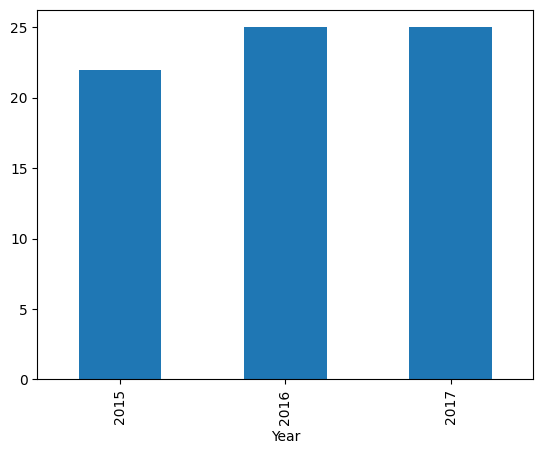

In [207]:
#How many exams per year for Mott Hall II?

mott_hall2.groupby(["Year"])["School DBN"].count().sort_values(ascending=True).plot(kind='bar')

<Axes: >

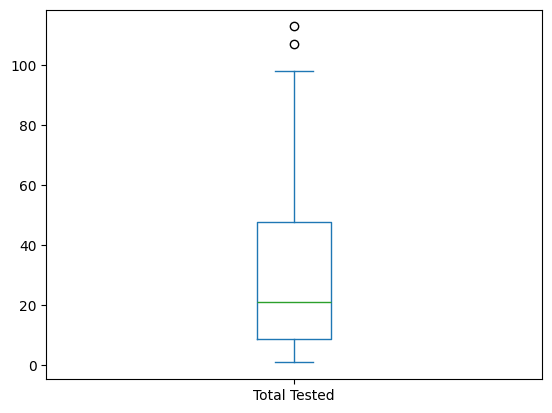

In [206]:
#What is the distribution of Regents Exam scores at Mott Hall II?

mott_hall2.plot.box(x="Mean Score", y="Total Tested")

<Axes: xlabel='Regents Exam'>

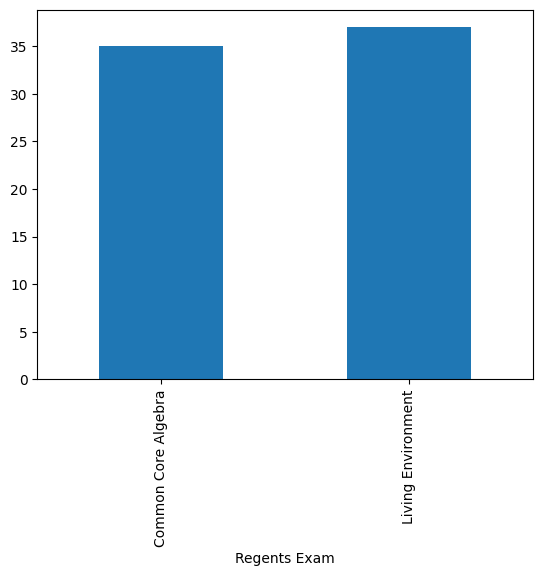

In [205]:
#How many Common Core Algebra Exams for Mott Hall II?

mott_hall2.groupby(["Regents Exam"])["index"].count().sort_values(ascending=True).plot(kind='bar')

In [204]:
#Compare Mott Hall II's Common Core Algebra scores over the years.

mh2_cca = mott_hall2_nn[mott_hall2_nn["Regents Exam"] == "Common Core Algebra"]
mh2_cca.groupby(["Year"])["Mean Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2015,9.0,71.800000,1.035616,70.1,71.200,72.00,72.300,73.4
2016,8.0,79.937500,2.007797,77.6,78.275,79.75,81.100,83.1
2017,6.0,82.583333,1.108903,81.3,81.675,82.70,83.125,84.2


Conclusion:
  The comparison record, Mott Hall II class with index #61468, had a higher average test score (Mean Score = 80.7) than other Mott Hall II classes (average Mean Score = 79.198077); however, the class average was not significantly higher. Mott Hall II had the highest Common Core Algebra scores in 2017. The scores improved each year, with a marked improvement between 2015 and 2016.